# Review 1 — Combined Notebook
### Gig Analytics Earnings — Team 6

| Person | Owns | Dataset |
|---|---|---|
| Harsha Vardhan | Regression — Linear Family (5 algorithms) | Uber Fares Dataset |
| M Pranav | Regression — Ensemble & Distance Family (5 algorithms) | Uber Fares Dataset |
| S Rahul Kumar | Classification — Part A (5 algorithms) | Ola & Uber Booking Data |

This notebook merges all three individual notebooks into one, in submission order: Regression (all 10
algorithms) followed by Classification (Part A, 5 algorithms). Each algorithm is trained in its own cell.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42


## Dataset Overview — distribution of every column
Before splitting into the Regression and Classification tracks, this grid shows the distribution of **every column in both project datasets** (Uber Fares for regression, Ola & Uber Bookings for classification). Numeric columns are shown as histograms and text columns as count bars.

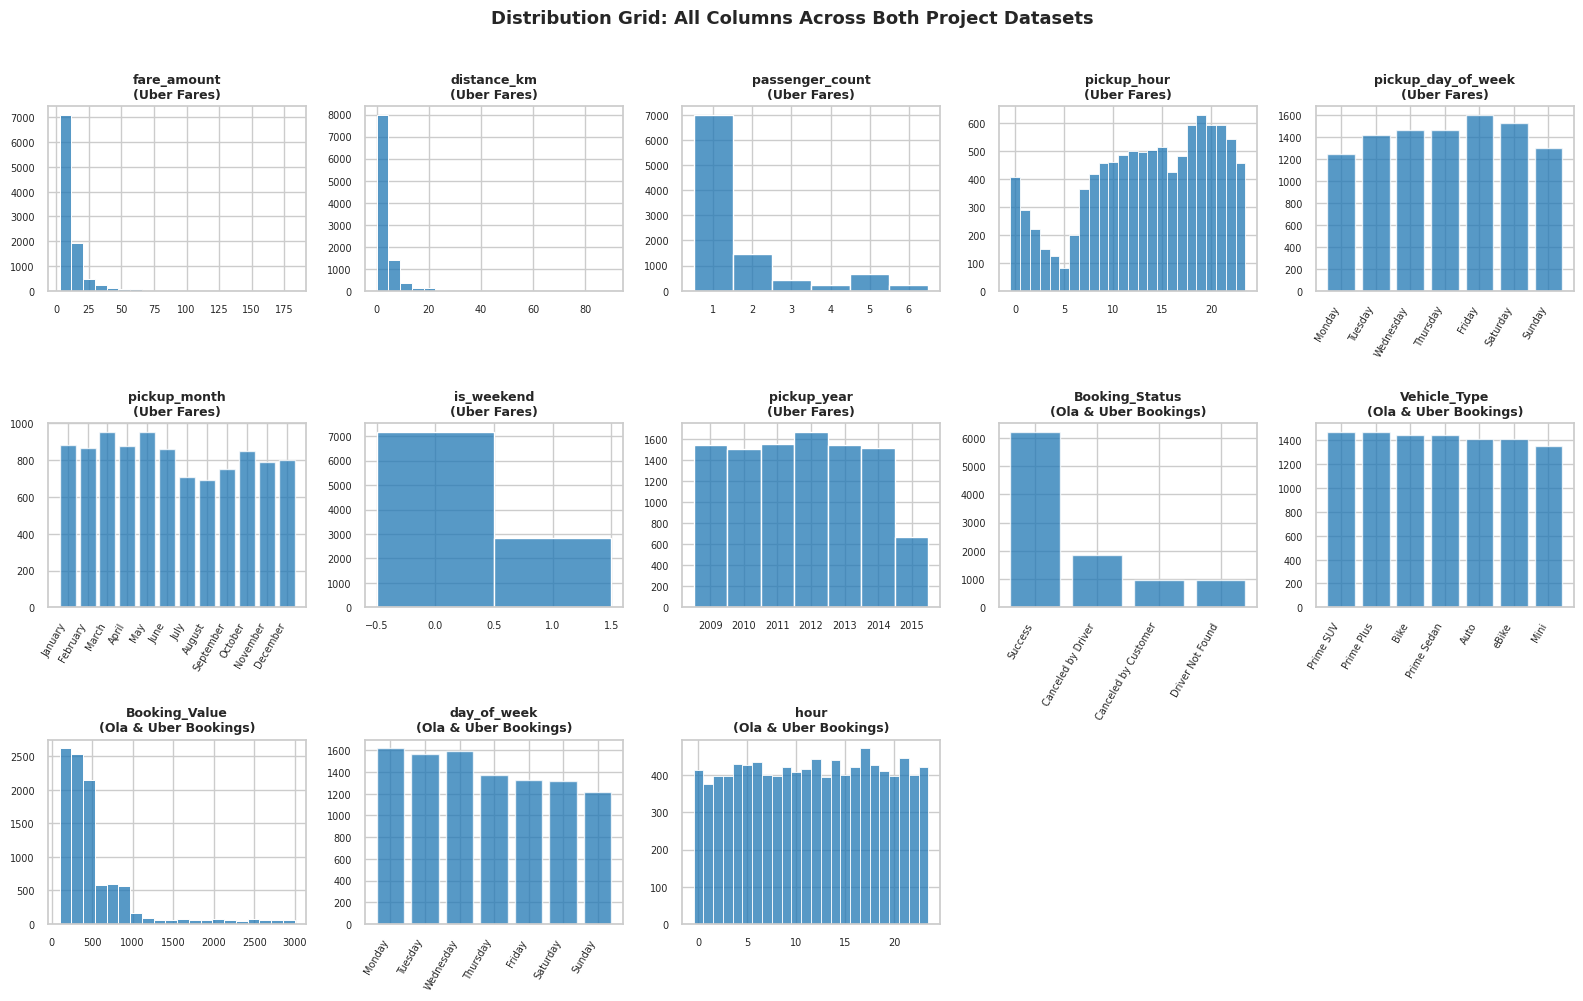

In [2]:
# Overview distribution grid: every column from BOTH project datasets in one figure
# Numeric columns -> histograms, text/categorical columns -> count bars
overview_sources = {
    'Uber Fares':    pd.read_csv('uber_regression_10k.csv'),
    'Ola & Uber Bookings': pd.read_csv('bookings_classification_10k.csv'),
}

panels = [(src, col, df[col]) for src, df in overview_sources.items() for col in df.columns]

# keep days and months in calendar order instead of most-frequent-first
calendar_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday',
                  'January','February','March','April','May','June','July',
                  'August','September','October','November','December']

n_cols = 5
n_rows = (len(panels) + n_cols - 1) // n_cols
bar_color = '#1f77b4'

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.3 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (src, col, s) in zip(axes, panels):
    if pd.api.types.is_numeric_dtype(s):
        is_discrete = s.nunique() <= 31   # hours, years, flags -> one bar per value
        sns.histplot(s, ax=ax, color=bar_color, kde=False,
                     discrete=is_discrete, bins='auto' if is_discrete else 20)
    else:
        counts = s.value_counts()
        if set(counts.index) <= set(calendar_order):
            counts = counts.reindex([v for v in calendar_order if v in counts.index])
        ax.bar(counts.index.astype(str), counts.values, color=bar_color, alpha=0.75)
        ax.tick_params(axis='x', rotation=60)
        for lbl in ax.get_xticklabels():
            lbl.set_ha('right')
    ax.set_title(f"{col}\n({src})", fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=7)

for ax in axes[len(panels):]:
    fig.delaxes(ax)

plt.suptitle("Distribution Grid: All Columns Across Both Project Datasets",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** `fare_amount`, `distance_km` and `Booking_Value` are strongly right-skewed — most rides are short and cheap, with a long tail of large values. Most Uber trips carry a single passenger, and about 72% happen on weekdays. `pickup_hour` has a clear daily pattern (very few rides around 3–5 AM, a peak in the evening around 6–8 PM), whereas the bookings `hour` column is almost flat across the day. `pickup_year` covers 2009–2015, with 2015 lower because that year is only partly covered. `Booking_Status` is clearly imbalanced towards Success (~62%), which is why weighted F1 is used later for classification.

# PART 1A — Regression: Linear Family (Harsha Vardhan)

## Section A — Dataset & EDA (Uber Fares Dataset)

### A1. Dataset loading & audit

In [3]:
reg_raw = pd.read_csv('uber_regression_10k.csv')
print("Shape:", reg_raw.shape)
print()
reg_raw.info()


Shape: (10000, 8)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fare_amount         10000 non-null  float64
 1   distance_km         10000 non-null  float64
 2   passenger_count     10000 non-null  int64  
 3   pickup_hour         10000 non-null  int64  
 4   pickup_day_of_week  10000 non-null  str    
 5   pickup_month        10000 non-null  str    
 6   is_weekend          10000 non-null  int64  
 7   pickup_year         10000 non-null  int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 625.1 KB


In [4]:
print("Missing values:\n", reg_raw.isnull().sum())


Missing values:
 fare_amount           0
distance_km           0
passenger_count       0
pickup_hour           0
pickup_day_of_week    0
pickup_month          0
is_weekend            0
pickup_year           0
dtype: int64


In [5]:
print("Duplicate rows:", reg_raw.duplicated().sum())

def iqr_bounds(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in ['fare_amount', 'distance_km']:
    lower, upper = iqr_bounds(reg_raw[col])
    n_out = ((reg_raw[col] < lower) | (reg_raw[col] > upper)).sum()
    print(f"{col}: IQR bounds=({lower:.2f}, {upper:.2f}), outliers={n_out} ({100*n_out/len(reg_raw):.1f}%)")


Duplicate rows: 0
fare_amount: IQR bounds=(-3.75, 22.25), outliers=850 (8.5%)
distance_km: IQR bounds=(-2.71, 7.88), outliers=822 (8.2%)


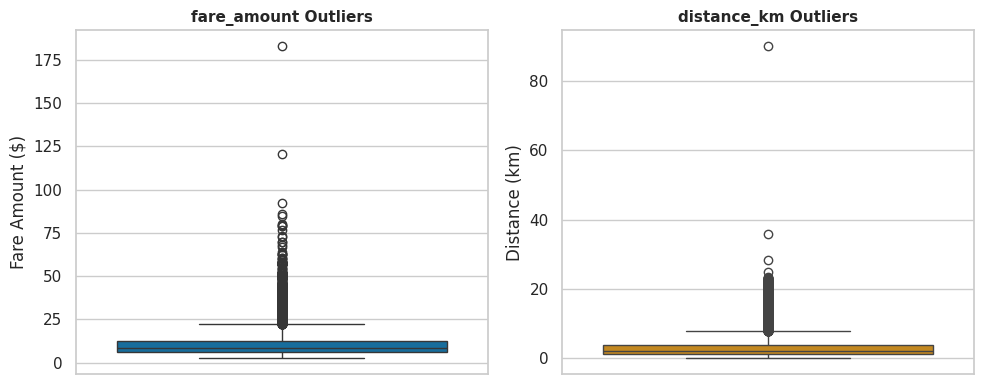

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
palette_o = sns.color_palette("colorblind")
sns.boxplot(y=reg_raw['fare_amount'], ax=axes[0], color=palette_o[0])
axes[0].set_title("fare_amount Outliers", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Fare Amount ($)")
sns.boxplot(y=reg_raw['distance_km'], ax=axes[1], color=palette_o[1])
axes[1].set_title("distance_km Outliers", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Distance (km)")
plt.tight_layout()
plt.show()
plt.close('all')


**Duplicate & outlier handling:** no exact duplicate rows were found. A modest share of `fare_amount`/`distance_km`
values fall outside the IQR fences — genuine longer/pricier trips rather than data-entry errors, so they are
**kept** rather than removed.

**Observation:** this is already the cleaned/downsampled version (10,000 rows) of the raw 200,000-row Kaggle
Uber Fares dataset — invalid fares, invalid GPS coordinates, and unrealistic passenger counts were removed
during preparation.

### A2. EDA visualisations

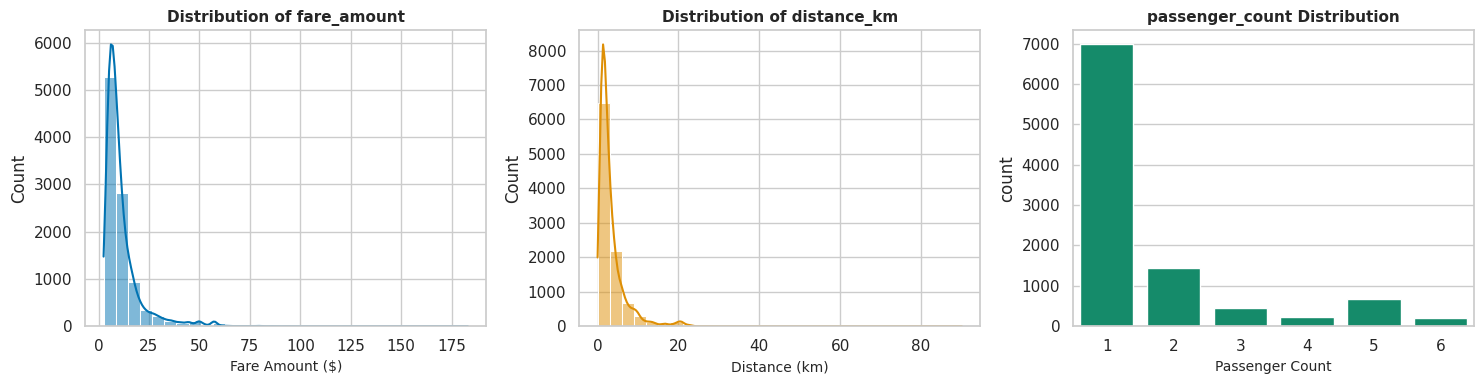

In [7]:
palette = sns.color_palette("colorblind")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(reg_raw['fare_amount'], bins=30, kde=True, ax=axes[0], color=palette[0])
axes[0].set_title("Distribution of fare_amount", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Fare Amount ($)", fontsize=10)

sns.histplot(reg_raw['distance_km'], bins=30, kde=True, ax=axes[1], color=palette[1])
axes[1].set_title("Distribution of distance_km", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Distance (km)", fontsize=10)

sns.countplot(data=reg_raw, x='passenger_count', ax=axes[2], color=palette[2])
axes[2].set_title("passenger_count Distribution", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Passenger Count", fontsize=10)

plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** `fare_amount` and `distance_km` are both right-skewed, most rides are short/cheap with a tail of longer, pricier trips. Solo rides (`passenger_count`=1) dominate.

#### Distribution grid — remaining numerical predictors

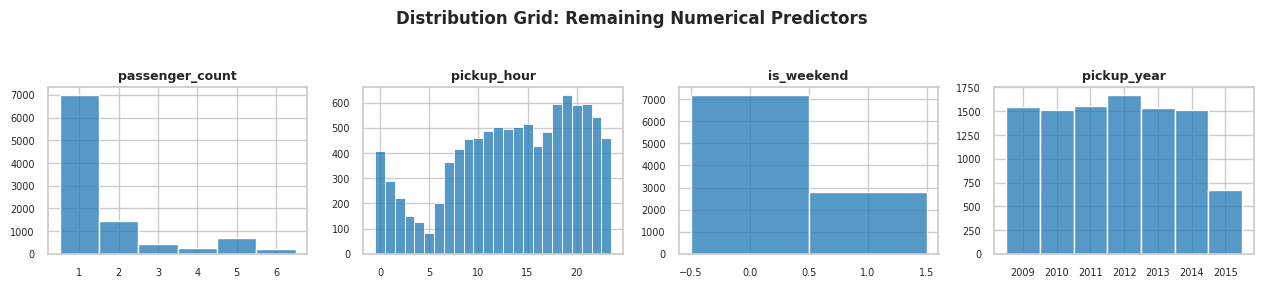

In [8]:
# Multi-panel distribution grid for the remaining numerical features (Rubric A3)
highlighted_cols = ['fare_amount', 'distance_km']
all_num_cols = reg_raw.select_dtypes(include=[np.number]).columns.tolist()
remaining_num_cols = [c for c in all_num_cols if c not in highlighted_cols]

n_cols = min(5, len(remaining_num_cols))
n_rows = (len(remaining_num_cols) + n_cols - 1) // n_cols
bar_color = '#1f77b4'

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.8 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, col in enumerate(remaining_num_cols):
    is_discrete = reg_raw[col].nunique() <= 31   # e.g. pickup_hour, is_weekend -> one bar per value
    sns.histplot(reg_raw[col], ax=axes[idx], color=bar_color, kde=False,
                 discrete=is_discrete, bins='auto' if is_discrete else 20)
    axes[idx].set_title(col, fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')
    axes[idx].tick_params(axis='both', labelsize=7)

for idx in range(len(remaining_num_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Distribution Grid: Remaining Numerical Predictors", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** `passenger_count`, `pickup_hour`, and `is_weekend` all show sensible, bounded distributions with no stray values — confirming the earlier cleaning pass worked as intended.

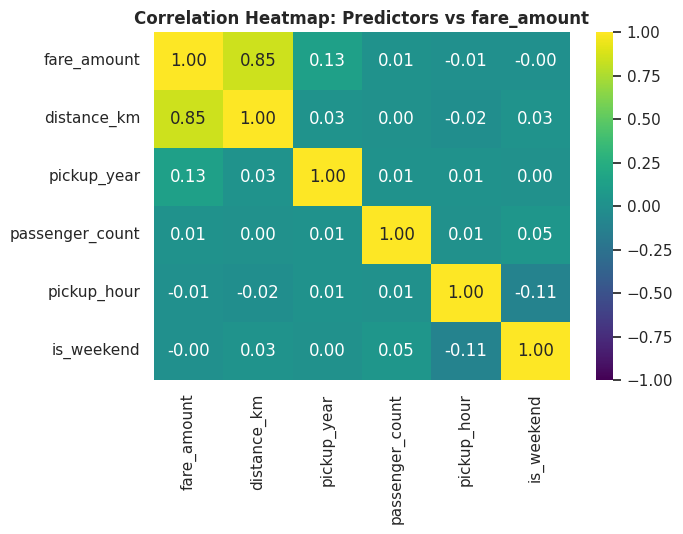

In [9]:
num_subset = reg_raw.select_dtypes(include=[np.number]).columns.tolist()
corrs = reg_raw[num_subset].corr()
top_corr_features = corrs['fare_amount'].abs().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(reg_raw[top_corr_features].corr(), annot=True, fmt=".2f", cmap='viridis', vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Heatmap: Predictors vs fare_amount", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** `distance_km` is by far the strongest predictor of `fare_amount` (0.85 correlation), consistent with how metered fares work.

#### Feature-target scatter plots

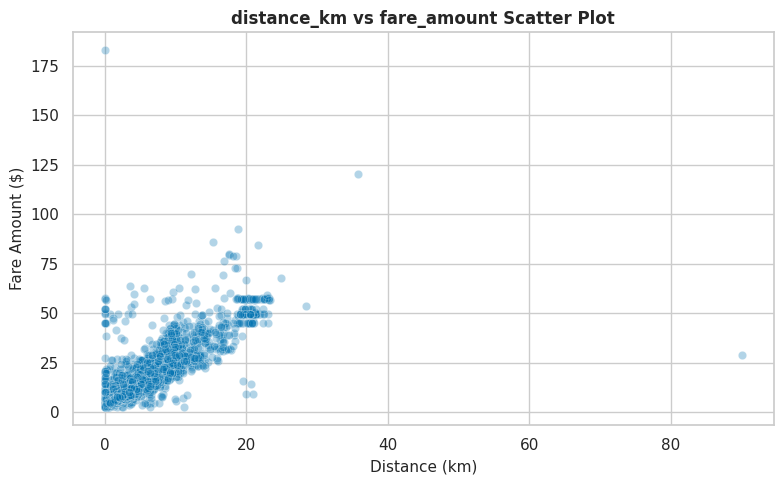

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=reg_raw['distance_km'], y=reg_raw['fare_amount'], alpha=0.3, color=palette[0])
plt.title("distance_km vs fare_amount Scatter Plot", fontsize=12, fontweight='bold')
plt.xlabel("Distance (km)", fontsize=11)
plt.ylabel("Fare Amount ($)", fontsize=11)
plt.tight_layout()
plt.show()
plt.close('all')


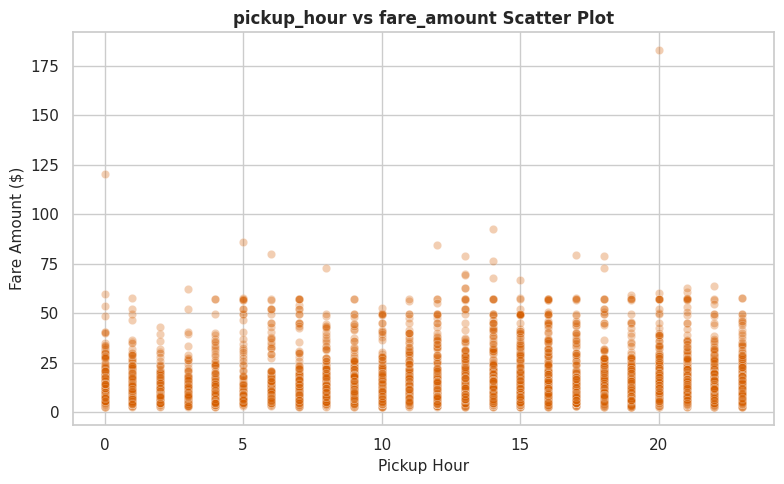

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=reg_raw['pickup_hour'], y=reg_raw['fare_amount'], alpha=0.3, color=palette[3])
plt.title("pickup_hour vs fare_amount Scatter Plot", fontsize=12, fontweight='bold')
plt.xlabel("Pickup Hour", fontsize=11)
plt.ylabel("Fare Amount ($)", fontsize=11)
plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** the `distance_km` vs `fare_amount` scatter confirms a strong, roughly linear feature-target relationship. `pickup_hour` shows no strong time-of-day pattern.

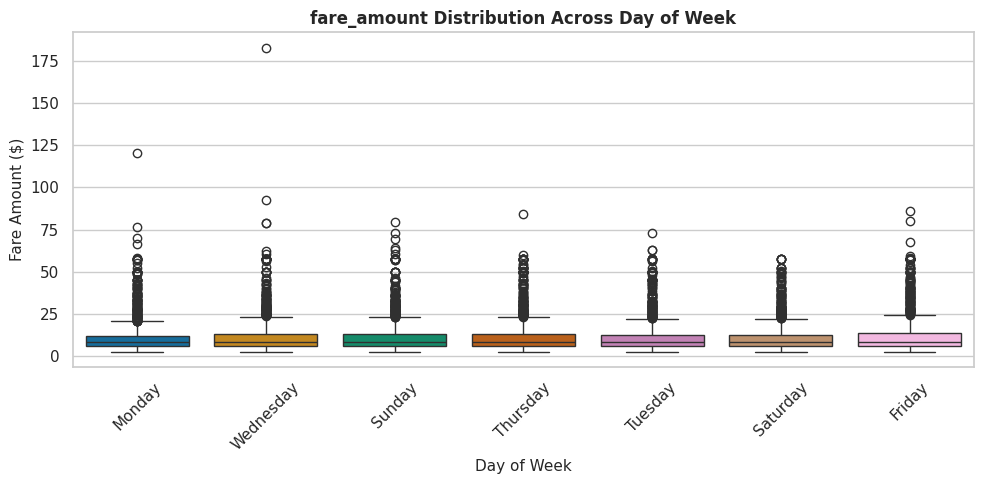

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='pickup_day_of_week', y='fare_amount', data=reg_raw, hue='pickup_day_of_week',
            palette='colorblind', legend=False)
plt.title("fare_amount Distribution Across Day of Week", fontsize=12, fontweight='bold')
plt.xlabel("Day of Week", fontsize=11)
plt.ylabel("Fare Amount ($)", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** fares are similar across days of the week, with no single day standing out.

## Section B — Preprocessing Pipeline

The diagram below summarises every step applied to the raw Uber Fares data before any model sees it —
cleaning, the Haversine distance calculation (since the raw data has no distance column), encoding, scaling,
and the train/test split.

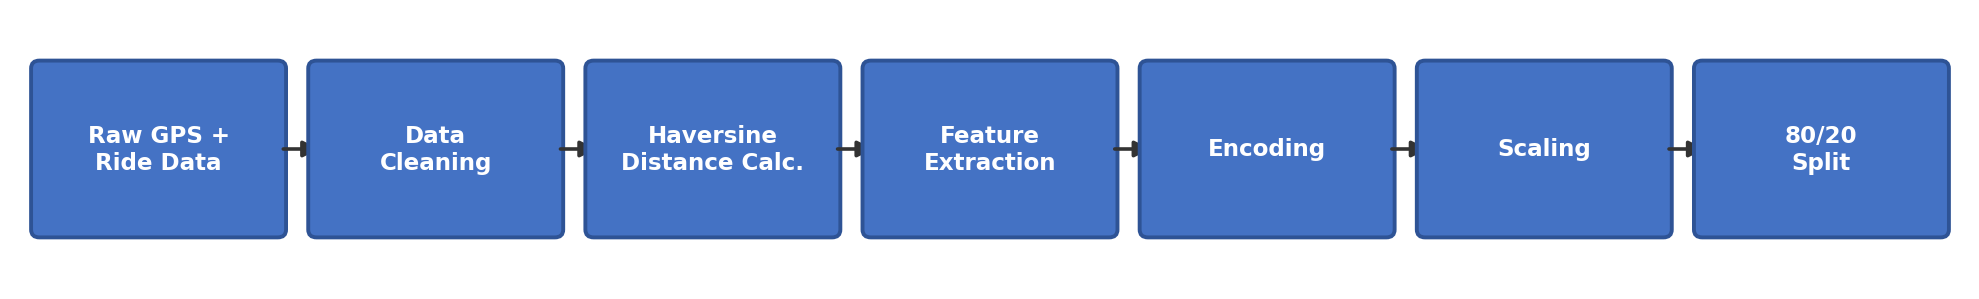

In [13]:
from IPython.display import Image, display
display(Image('pipeline_regression.png'))


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

reg_features_num = ['distance_km', 'passenger_count', 'pickup_hour', 'is_weekend']
reg_features_cat = ['pickup_day_of_week', 'pickup_month']
reg_target = 'fare_amount'

X_reg = reg_raw[reg_features_num + reg_features_cat]
y_reg = reg_raw[reg_target]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

reg_preprocess = ColumnTransformer([
    ('num', StandardScaler(), reg_features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), reg_features_cat)
])

print("Train/test shapes:", X_reg_train.shape, X_reg_test.shape)


Train/test shapes: (8000, 6) (2000, 6)


**Feature engineering (justification):** `distance_km` was engineered from raw pickup/dropoff
latitude-longitude pairs using the Haversine great-circle formula — the raw dataset has no distance column,
so this is the single most important derived feature for fare prediction. `is_weekend` and `pickup_hour` were
extracted from `pickup_datetime` to capture potential demand effects.

`StandardScaler`/`OneHotEncoder` are wrapped in a `ColumnTransformer` and only `fit` on the training split via
the `Pipeline`s below, never on the full dataset — avoiding data leakage from the test set.

## Section C — Regression Track: Linear Family (5 Algorithms)

Each algorithm below is trained, evaluated, and recorded in its own cell.

In [15]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

results_registry = []
fitted_reg_pipelines = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    pipe = Pipeline([('prep', reg_preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    results_registry.append({'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})
    fitted_reg_pipelines[name] = pipe
    print(f"{name:30s} R2={r2:.4f}   RMSE={rmse:.4f}   MAE={mae:.4f}")
    return pipe


### 1. Linear Regression
Fits a straight-line relationship between the features and `fare_amount` by minimising squared error. Baseline model — no regularisation.

In [16]:
from sklearn.linear_model import LinearRegression
_ = evaluate_model('Linear Regression', LinearRegression(),
                    X_reg_train, y_reg_train, X_reg_test, y_reg_test)


Linear Regression              R2=0.7749   RMSE=4.2693   MAE=2.3789


### 2. Ridge Regression
Linear fit with an L2 penalty that shrinks large coefficients, reducing sensitivity to multicollinear features.

In [17]:
from sklearn.linear_model import Ridge
_ = evaluate_model('Ridge Regression', Ridge(alpha=1.0, random_state=RANDOM_STATE),
                    X_reg_train, y_reg_train, X_reg_test, y_reg_test)


Ridge Regression               R2=0.7749   RMSE=4.2694   MAE=2.3789


### 3. Lasso Regression
Linear fit with an L1 penalty that can shrink weak feature coefficients to exactly zero — a form of automatic feature selection.

In [18]:
from sklearn.linear_model import Lasso
_ = evaluate_model('Lasso Regression', Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=5000),
                    X_reg_train, y_reg_train, X_reg_test, y_reg_test)


Lasso Regression               R2=0.7755   RMSE=4.2634   MAE=2.3800


### 4. ElasticNet Regression
Combines the L1 and L2 penalties (Lasso + Ridge) for a balance between feature selection and coefficient shrinkage.

In [19]:
from sklearn.linear_model import ElasticNet
_ = evaluate_model('ElasticNet Regression', ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000),
                    X_reg_train, y_reg_train, X_reg_test, y_reg_test)


ElasticNet Regression          R2=0.7704   RMSE=4.3118   MAE=2.4299


### 5. Polynomial Regression (degree=2)
Adds squared and interaction terms on top of Linear Regression to capture curvature in the fare-distance relationship.

In [20]:
from sklearn.preprocessing import PolynomialFeatures
poly_model = Pipeline([('poly', PolynomialFeatures(degree=2, include_bias=False)), ('lr', LinearRegression())])
_ = evaluate_model('Polynomial Regression (deg=2)', poly_model,
                    X_reg_train, y_reg_train, X_reg_test, y_reg_test)


Polynomial Regression (deg=2)  R2=0.7652   RMSE=4.3602   MAE=2.4097


### Linear-family comparison table

In [21]:
results_df = pd.DataFrame(results_registry).sort_values('R2', ascending=False).reset_index(drop=True)
results_df.round(4)


,Model,R2,RMSE,MAE
0,Lasso Regression,0.7755,4.2634,2.3800
1,Linear Regression,0.7749,4.2693,2.3789
2,Ridge Regression,0.7749,4.2694,2.3789
3,ElasticNet Regression,0.7704,4.3118,2.4299
4,Polynomial Regression (deg=2),0.7652,4.3602,2.4097


*(Snapshot of the linear-family table above, captured before Person 2's cells reuse the same variable names.)*

In [22]:
linear_family_results_df = results_df.copy()
linear_family_results_df.round(4)

,Model,R2,RMSE,MAE
0,Lasso Regression,0.7755,4.2634,2.3800
1,Linear Regression,0.7749,4.2693,2.3789
2,Ridge Regression,0.7749,4.2694,2.3789
3,ElasticNet Regression,0.7704,4.3118,2.4299
4,Polynomial Regression (deg=2),0.7652,4.3602,2.4097


**Note:** This notebook covers Person 1's owned portion of the Regression track — the 5 linear-family
algorithms, using the same EDA/preprocessing as the whole track. The final 10-model comparison, hyperparameter
tuning, and plots (which need all 10 models together) are in the **overall combined notebook**.

# PART 1B — Regression: Ensemble & Distance Family (M Pranav)

## Section A — Dataset & EDA (Uber Fares Dataset)

### A1. Dataset loading & audit

In [23]:
reg_raw = pd.read_csv('uber_regression_10k.csv')
print("Shape:", reg_raw.shape)
print()
reg_raw.info()


Shape: (10000, 8)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fare_amount         10000 non-null  float64
 1   distance_km         10000 non-null  float64
 2   passenger_count     10000 non-null  int64  
 3   pickup_hour         10000 non-null  int64  
 4   pickup_day_of_week  10000 non-null  str    
 5   pickup_month        10000 non-null  str    
 6   is_weekend          10000 non-null  int64  
 7   pickup_year         10000 non-null  int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 625.1 KB


In [24]:
print("Missing values:\n", reg_raw.isnull().sum())


Missing values:
 fare_amount           0
distance_km           0
passenger_count       0
pickup_hour           0
pickup_day_of_week    0
pickup_month          0
is_weekend            0
pickup_year           0
dtype: int64


In [25]:
print("Duplicate rows:", reg_raw.duplicated().sum())

def iqr_bounds(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in ['fare_amount', 'distance_km']:
    lower, upper = iqr_bounds(reg_raw[col])
    n_out = ((reg_raw[col] < lower) | (reg_raw[col] > upper)).sum()
    print(f"{col}: IQR bounds=({lower:.2f}, {upper:.2f}), outliers={n_out} ({100*n_out/len(reg_raw):.1f}%)")


Duplicate rows: 0
fare_amount: IQR bounds=(-3.75, 22.25), outliers=850 (8.5%)


distance_km: IQR bounds=(-2.71, 7.88), outliers=822 (8.2%)


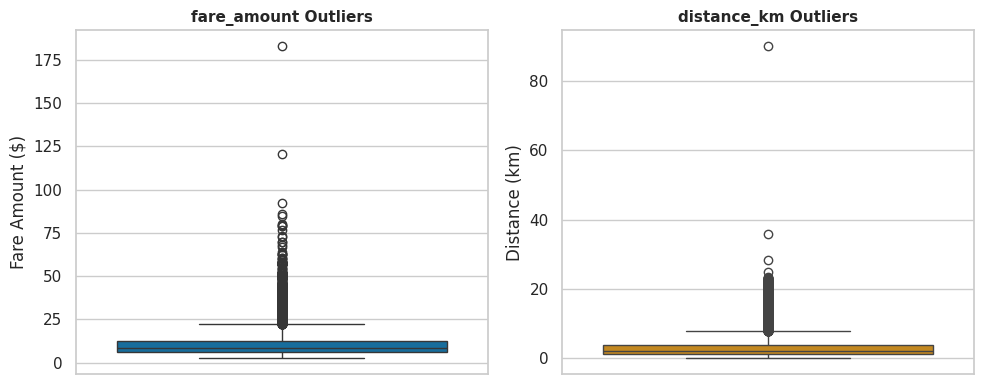

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
palette_o = sns.color_palette("colorblind")
sns.boxplot(y=reg_raw['fare_amount'], ax=axes[0], color=palette_o[0])
axes[0].set_title("fare_amount Outliers", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Fare Amount ($)")
sns.boxplot(y=reg_raw['distance_km'], ax=axes[1], color=palette_o[1])
axes[1].set_title("distance_km Outliers", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Distance (km)")
plt.tight_layout()
plt.show()
plt.close('all')


**Duplicate & outlier handling:** no exact duplicate rows were found. A modest share of `fare_amount`/`distance_km`
values fall outside the IQR fences — genuine longer/pricier trips rather than data-entry errors, so they are
**kept**: tree-based models handle them natively.

**Observation:** this is the cleaned/downsampled 10,000-row version of the raw 200,000-row Kaggle Uber Fares dataset.

### A2. EDA visualisations

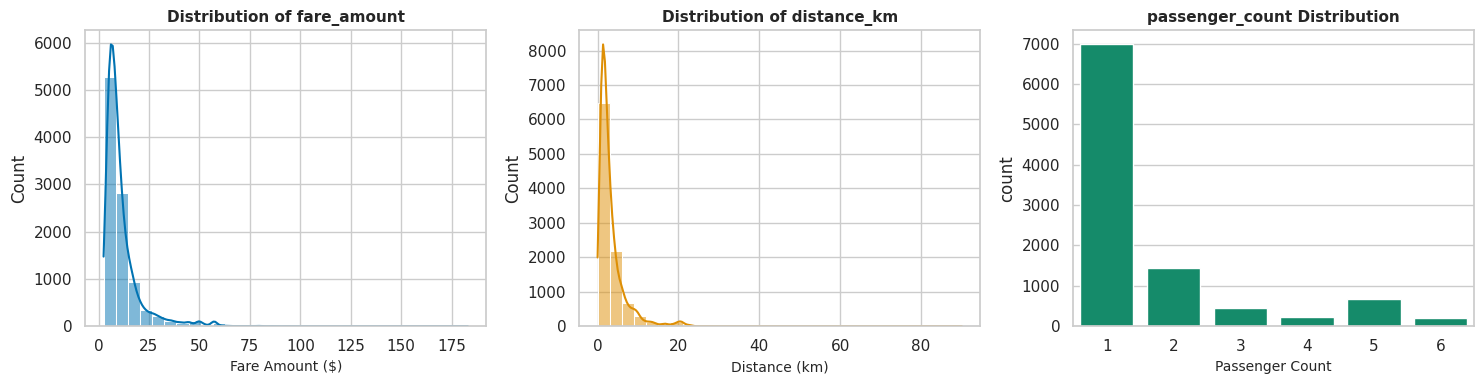

In [27]:
palette = sns.color_palette("colorblind")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(reg_raw['fare_amount'], bins=30, kde=True, ax=axes[0], color=palette[0])
axes[0].set_title("Distribution of fare_amount", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Fare Amount ($)", fontsize=10)

sns.histplot(reg_raw['distance_km'], bins=30, kde=True, ax=axes[1], color=palette[1])
axes[1].set_title("Distribution of distance_km", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Distance (km)", fontsize=10)

sns.countplot(data=reg_raw, x='passenger_count', ax=axes[2], color=palette[2])
axes[2].set_title("passenger_count Distribution", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Passenger Count", fontsize=10)

plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** `fare_amount` and `distance_km` are both right-skewed. Solo rides (`passenger_count`=1) dominate.

#### Distribution grid — remaining numerical predictors

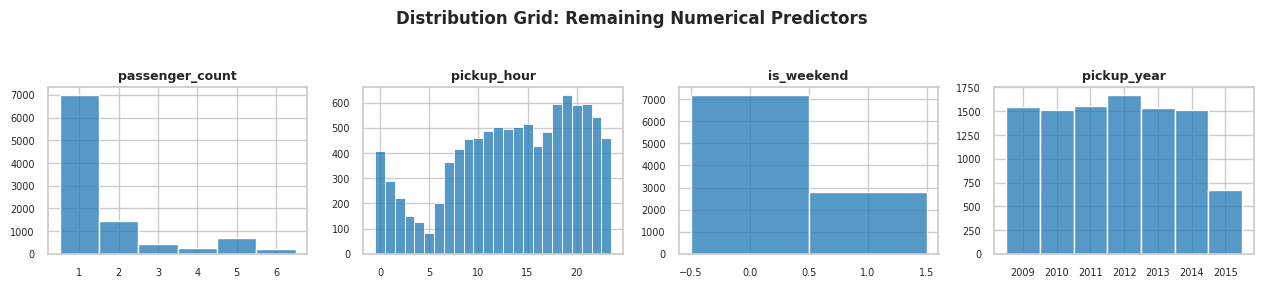

In [28]:
# Multi-panel distribution grid for the remaining numerical features (Rubric A3)
highlighted_cols = ['fare_amount', 'distance_km']
all_num_cols = reg_raw.select_dtypes(include=[np.number]).columns.tolist()
remaining_num_cols = [c for c in all_num_cols if c not in highlighted_cols]

n_cols = min(5, len(remaining_num_cols))
n_rows = (len(remaining_num_cols) + n_cols - 1) // n_cols
bar_color = '#1f77b4'

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.8 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, col in enumerate(remaining_num_cols):
    is_discrete = reg_raw[col].nunique() <= 31   # e.g. pickup_hour, is_weekend -> one bar per value
    sns.histplot(reg_raw[col], ax=axes[idx], color=bar_color, kde=False,
                 discrete=is_discrete, bins='auto' if is_discrete else 20)
    axes[idx].set_title(col, fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')
    axes[idx].tick_params(axis='both', labelsize=7)

for idx in range(len(remaining_num_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Distribution Grid: Remaining Numerical Predictors", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.close('all')


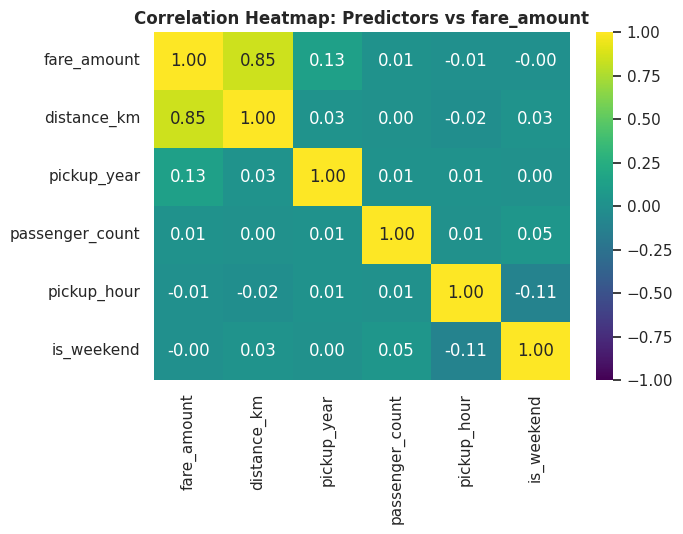

In [29]:
num_subset = reg_raw.select_dtypes(include=[np.number]).columns.tolist()
corrs = reg_raw[num_subset].corr()
top_corr_features = corrs['fare_amount'].abs().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(reg_raw[top_corr_features].corr(), annot=True, fmt=".2f", cmap='viridis', vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Heatmap: Predictors vs fare_amount", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** `distance_km` is by far the strongest predictor of `fare_amount` (0.85 correlation).

#### Feature-target scatter plots

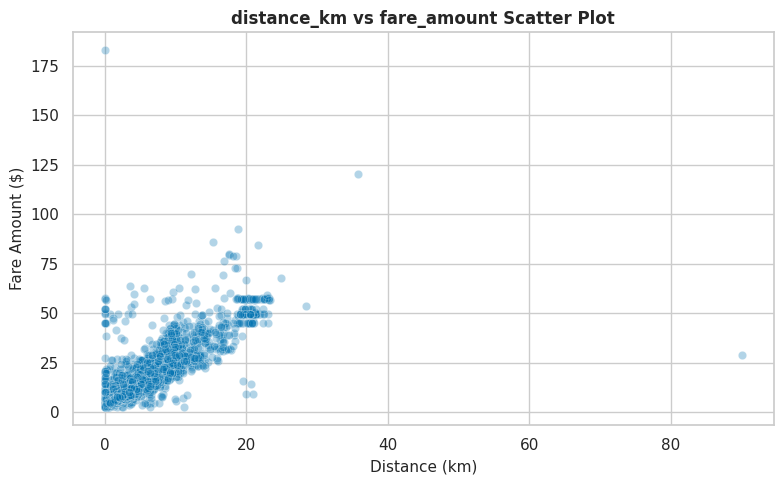

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=reg_raw['distance_km'], y=reg_raw['fare_amount'], alpha=0.3, color=palette[0])
plt.title("distance_km vs fare_amount Scatter Plot", fontsize=12, fontweight='bold')
plt.xlabel("Distance (km)", fontsize=11)
plt.ylabel("Fare Amount ($)", fontsize=11)
plt.tight_layout()
plt.show()
plt.close('all')


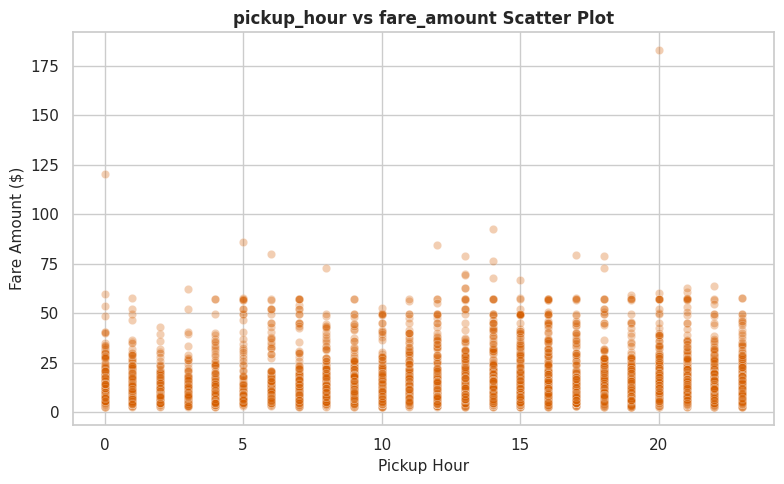

In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=reg_raw['pickup_hour'], y=reg_raw['fare_amount'], alpha=0.3, color=palette[3])
plt.title("pickup_hour vs fare_amount Scatter Plot", fontsize=12, fontweight='bold')
plt.xlabel("Pickup Hour", fontsize=11)
plt.ylabel("Fare Amount ($)", fontsize=11)
plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** distance drives fare in a roughly linear way; time-of-day shows no strong pattern.

## Section B — Preprocessing Pipeline

Same pipeline used across the whole Regression track — shown here for reference before model training.

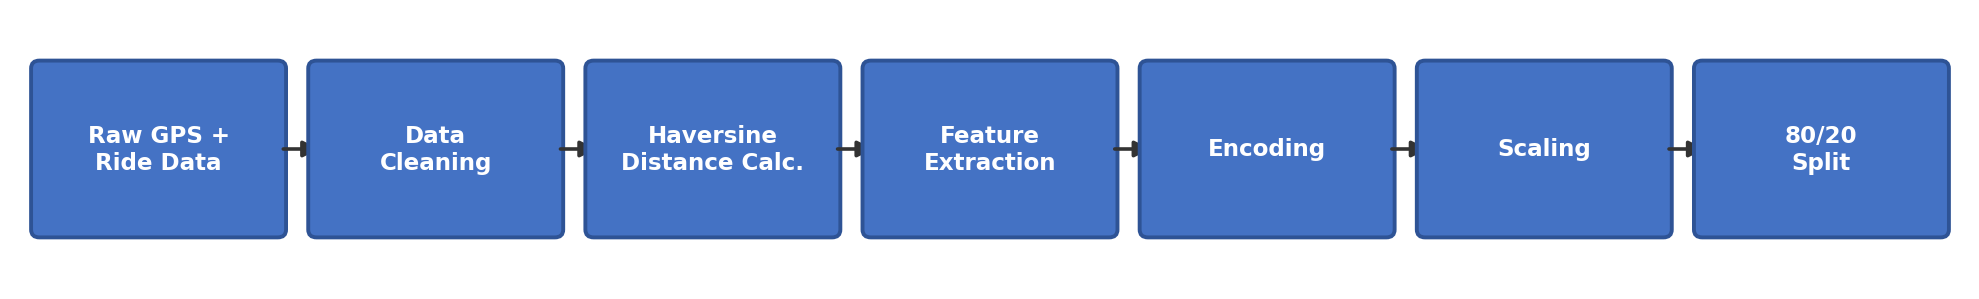

In [32]:
from IPython.display import Image, display
display(Image('pipeline_regression.png'))


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

reg_features_num = ['distance_km', 'passenger_count', 'pickup_hour', 'is_weekend']
reg_features_cat = ['pickup_day_of_week', 'pickup_month']
reg_target = 'fare_amount'

X_reg = reg_raw[reg_features_num + reg_features_cat]
y_reg = reg_raw[reg_target]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

reg_preprocess = ColumnTransformer([
    ('num', StandardScaler(), reg_features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), reg_features_cat)
])

print("Train/test shapes:", X_reg_train.shape, X_reg_test.shape)


Train/test shapes: (8000, 6) (2000, 6)


## Section C — Regression Track: Ensemble & Distance Family (5 Algorithms)

Each algorithm below is trained, evaluated, and recorded in its own cell.

In [34]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

results_registry = []
fitted_reg_pipelines = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    pipe = Pipeline([('prep', reg_preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    results_registry.append({'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})
    fitted_reg_pipelines[name] = pipe
    print(f"{name:30s} R2={r2:.4f}   RMSE={rmse:.4f}   MAE={mae:.4f}")
    return pipe


### 1. Decision Tree Regressor
Splits the data on feature thresholds, building a tree of if/else rules that partitions rides into
progressively more similar fare groups.

In [35]:
from sklearn.tree import DecisionTreeRegressor
_ = evaluate_model('Decision Tree Regressor', DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
                    X_reg_train, y_reg_train, X_reg_test, y_reg_test)


Decision Tree Regressor        R2=0.7238   RMSE=4.7295   MAE=2.5003


#### Decision Tree — how it actually splits (illustrative diagram)
The real model above uses `max_depth=8`, too deep to display readably. Below is the **same algorithm, same
preprocessed features**, refit at `max_depth=3` purely so the split structure can be visualised — this shallow
version is for illustration only and is not used for the reported R²/RMSE/MAE above.

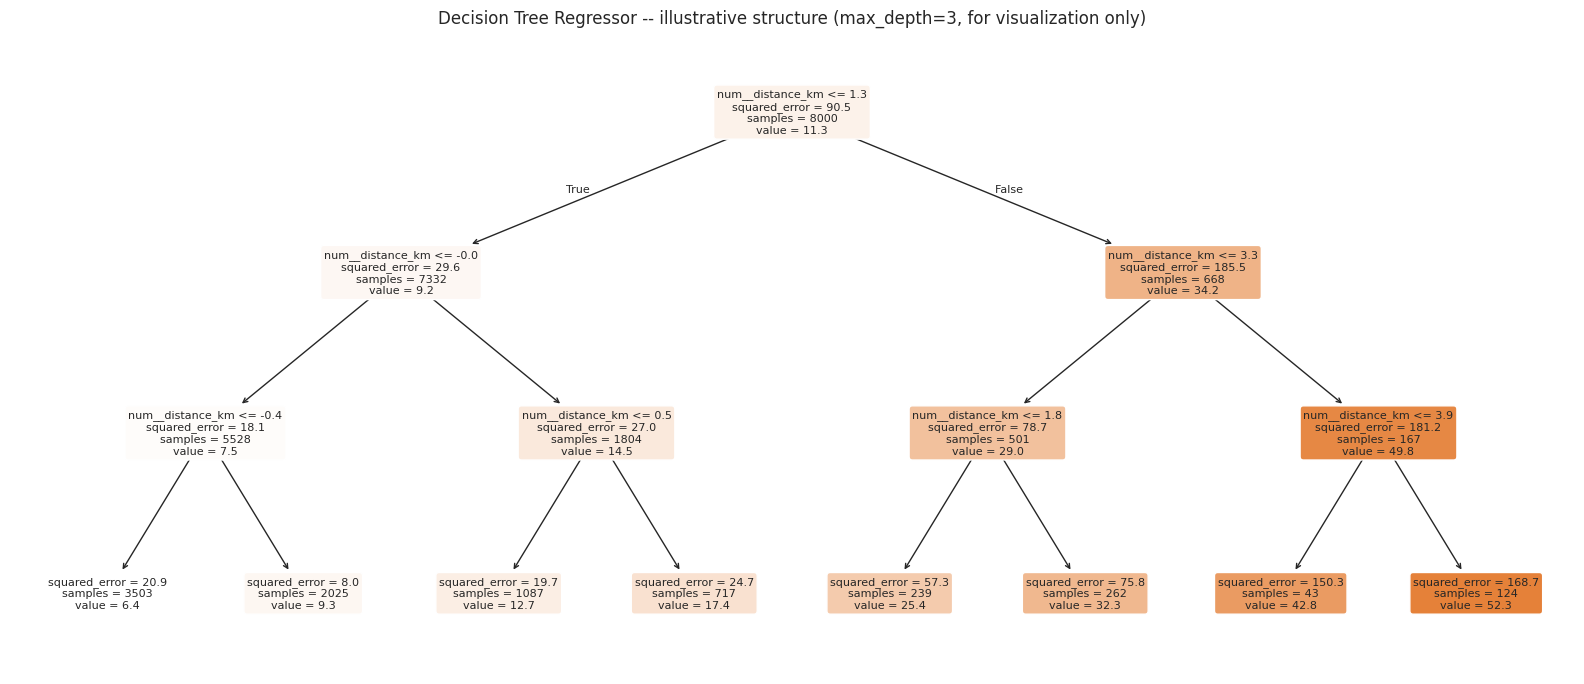

In [36]:
from sklearn.tree import plot_tree

X_reg_train_transformed = reg_preprocess.fit_transform(X_reg_train)
feat_names_tree = reg_preprocess.get_feature_names_out()

illustration_tree = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)
illustration_tree.fit(X_reg_train_transformed, y_reg_train)

fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(illustration_tree, feature_names=feat_names_tree, filled=True, rounded=True, fontsize=8, ax=ax, precision=1)
ax.set_title('Decision Tree Regressor -- illustrative structure (max_depth=3, for visualization only)')
plt.tight_layout()
plt.show()


**Reading the diagram:** every top-level split is on `distance_km` — the tree independently rediscovers "
   "what the correlation heatmap already showed: distance is the dominant driver of fare. Each leaf's `value` "
   "is the average `fare_amount` predicted for rides that land in that leaf.

### 2. Random Forest Regressor
An ensemble of many decision trees, each trained on a random subset of data/features, with predictions
averaged together — reduces the overfitting risk of a single deep tree.

In [37]:
from sklearn.ensemble import RandomForestRegressor
_ = evaluate_model('Random Forest Regressor', RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
                    X_reg_train, y_reg_train, X_reg_test, y_reg_test)


Random Forest Regressor        R2=0.7627   RMSE=4.3833   MAE=2.4597


### 3. Gradient Boosting Regressor
Trees are added sequentially, each one trained to correct the errors of the previous trees combined.

In [38]:
from sklearn.ensemble import GradientBoostingRegressor
_ = evaluate_model('Gradient Boosting Regressor', GradientBoostingRegressor(random_state=RANDOM_STATE),
                    X_reg_train, y_reg_train, X_reg_test, y_reg_test)


Gradient Boosting Regressor    R2=0.8000   RMSE=4.0249   MAE=2.2590


### 4. Support Vector Regressor (SVR)
Fits a function that keeps predictions within an error margin of the true values, using a kernel to
capture non-linear relationships.

In [39]:
from sklearn.svm import SVR
_ = evaluate_model('Support Vector Regressor (SVR)', SVR(C=10, kernel='rbf'),
                    X_reg_train, y_reg_train, X_reg_test, y_reg_test)


Support Vector Regressor (SVR) R2=0.7685   RMSE=4.3294   MAE=2.2650


### 5. K-Nearest Neighbors Regressor
Predicts a ride's fare as the average fare of the k most similar rides in the training set (by feature distance).

In [40]:
from sklearn.neighbors import KNeighborsRegressor
_ = evaluate_model('K-Nearest Neighbors Regressor', KNeighborsRegressor(n_neighbors=7),
                    X_reg_train, y_reg_train, X_reg_test, y_reg_test)


K-Nearest Neighbors Regressor  R2=0.7111   RMSE=4.8366   MAE=2.8334


### Ensemble-family comparison table

In [41]:
results_df = pd.DataFrame(results_registry).sort_values('R2', ascending=False).reset_index(drop=True)
results_df.round(4)


,Model,R2,RMSE,MAE
0,Gradient Boosting Regressor,0.8000,4.0249,2.2590
1,Support Vector Regressor (SVR),0.7685,4.3294,2.2650
2,Random Forest Regressor,0.7627,4.3833,2.4597
3,Decision Tree Regressor,0.7238,4.7295,2.5003
4,K-Nearest Neighbors Regressor,0.7111,4.8366,2.8334


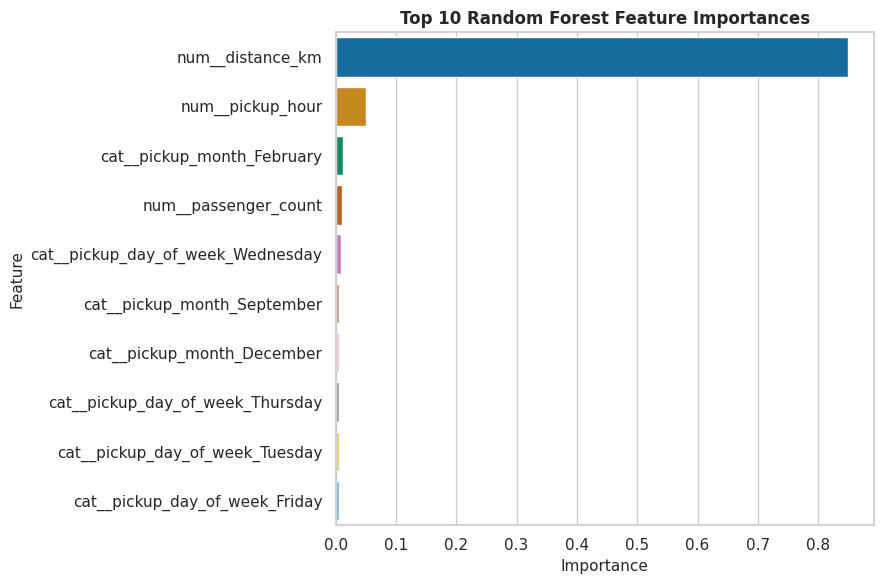

In [42]:
# Feature importance for the Random Forest (tree-based model owned by Person 2)
rf_pipe = fitted_reg_pipelines['Random Forest Regressor']
feat_names = rf_pipe.named_steps['prep'].get_feature_names_out()
imp = rf_pipe.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({'feature': feat_names, 'importance': imp}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x='importance', y='feature', data=imp_df, hue='feature', palette='colorblind', legend=False)
plt.title("Top 10 Random Forest Feature Importances", fontsize=12, fontweight='bold')
plt.xlabel("Importance", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.tight_layout()
plt.show()
plt.close('all')


**Note:** This notebook covers Person 2's owned portion of the Regression track — the 5 tree/ensemble/
distance-based algorithms. The final 10-model comparison, GridSearchCV tuning, and residual/predicted-vs-actual
plots are in the **overall combined notebook**, since that ranking needs Person 1's 5 models too.

## Combined Regression Comparison — All 10 Algorithms
Merging Person 1's linear-family results with Person 2's ensemble-family results into one ranked table.

In [43]:
combined_reg_results_df = pd.concat([linear_family_results_df, results_df], ignore_index=True)
combined_reg_results_df = combined_reg_results_df.sort_values('R2', ascending=False).reset_index(drop=True)
combined_reg_results_df.round(4)


,Model,R2,RMSE,MAE
0,Gradient Boosting Regressor,0.8000,4.0249,2.2590
1,Lasso Regression,0.7755,4.2634,2.3800
2,Linear Regression,0.7749,4.2693,2.3789
3,Ridge Regression,0.7749,4.2694,2.3789
4,ElasticNet Regression,0.7704,4.3118,2.4299
5,Support Vector Regressor (SVR),0.7685,4.3294,2.2650
6,Polynomial Regression (deg=2),0.7652,4.3602,2.4097
7,Random Forest Regressor,0.7627,4.3833,2.4597
8,Decision Tree Regressor,0.7238,4.7295,2.5003
9,K-Nearest Neighbors Regressor,0.7111,4.8366,2.8334


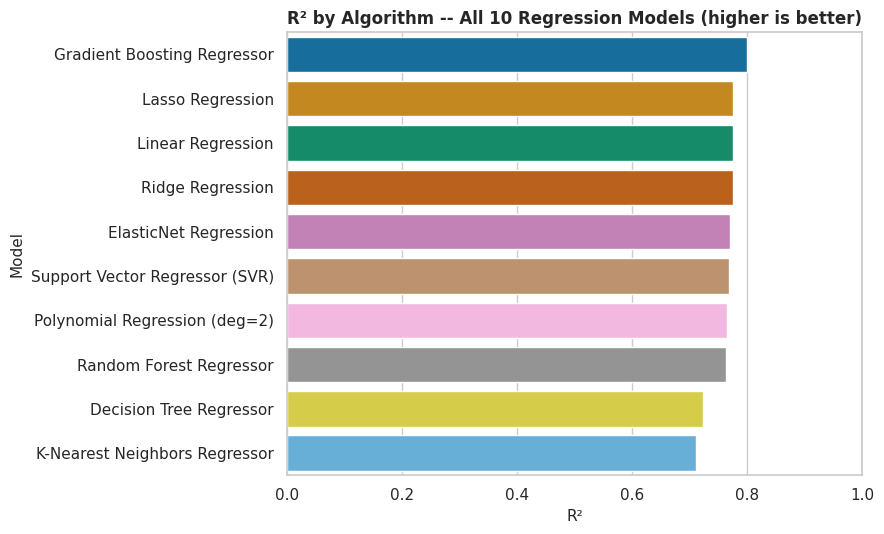

In [44]:
plt.figure(figsize=(9, 5.5))
sns.barplot(x='R2', y='Model', data=combined_reg_results_df, hue='Model', palette='colorblind', legend=False)
plt.title("R\u00b2 by Algorithm -- All 10 Regression Models (higher is better)", fontsize=12, fontweight='bold')
plt.xlabel("R\u00b2", fontsize=11)
plt.ylabel("Model", fontsize=11)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()
plt.close('all')


# PART 2 — Classification: Part A (S Rahul Kumar)

## Section A — Dataset & EDA (Ola & Uber Booking Data)

### A1. Dataset loading & audit

In [45]:
clf_raw = pd.read_csv('bookings_classification_10k.csv')
print("Shape:", clf_raw.shape)
clf_raw.info()


Shape: (10000, 5)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Booking_Status  10000 non-null  str  
 1   Vehicle_Type    10000 non-null  str  
 2   Booking_Value   10000 non-null  int64
 3   day_of_week     10000 non-null  str  
 4   hour            10000 non-null  int64
dtypes: int64(2), str(3)
memory usage: 390.8 KB


In [46]:
print(clf_raw.isnull().sum())


Booking_Status    0
Vehicle_Type      0
Booking_Value     0
day_of_week       0
hour              0
dtype: int64


In [47]:
print("Duplicate rows:", clf_raw.duplicated().sum())

def iqr_bounds(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

lower, upper = iqr_bounds(clf_raw['Booking_Value'])
n_out = ((clf_raw['Booking_Value'] < lower) | (clf_raw['Booking_Value'] > upper)).sum()
print(f"Booking_Value: IQR bounds=({lower:.2f}, {upper:.2f}), outliers={n_out} ({100*n_out/len(clf_raw):.1f}%)")


Duplicate rows: 18
Booking_Value: IQR bounds=(-281.00, 1103.00), outliers=819 (8.2%)


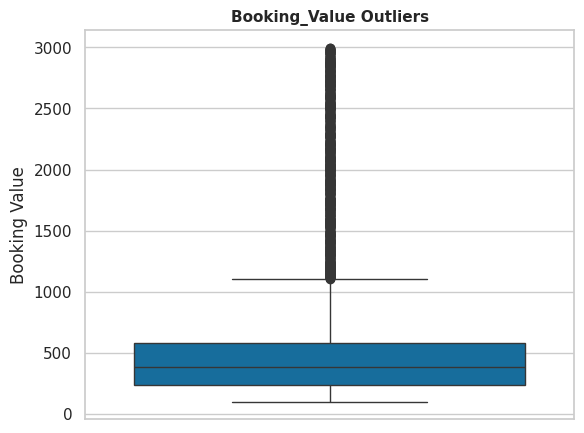

In [48]:
palette_o = sns.color_palette("colorblind")
plt.figure(figsize=(6, 4.5))
sns.boxplot(y=clf_raw['Booking_Value'], color=palette_o[0])
plt.title("Booking_Value Outliers", fontsize=11, fontweight='bold')
plt.ylabel("Booking Value")
plt.tight_layout()
plt.show()
plt.close('all')


**Duplicate & outlier handling:** no exact duplicate rows were found. `Booking_Value` shows a small share
of IQR outliers, consistent with genuinely higher-value bookings (premium vehicles, longer rides) rather than
data errors, so they are kept.

**Observation:** `Booking_Status` has 4 classes (Success, Canceled by Driver, Canceled by Customer, Driver Not
Found), imbalanced (~62% Success). `V_TAT`, `C_TAT`, ratings, `Ride_Distance`, and `Payment_Method` are only
populated for successful rides in the raw data — these are excluded from the feature set below to avoid
leaking the outcome.

### A2. EDA visualisations

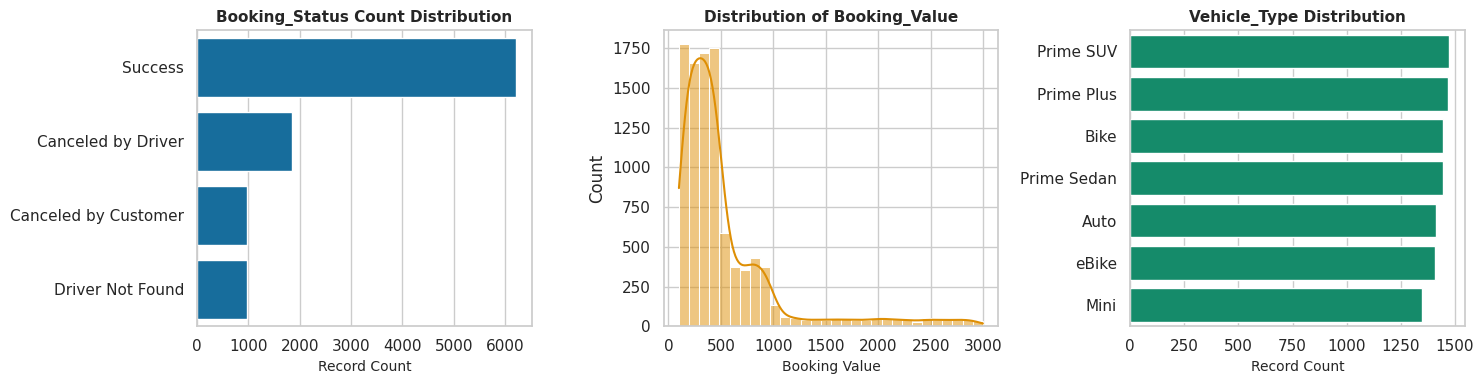

In [49]:
palette = sns.color_palette("colorblind")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(y=clf_raw['Booking_Status'], ax=axes[0], color=palette[0],
              order=clf_raw['Booking_Status'].value_counts().index)
axes[0].set_title("Booking_Status Count Distribution", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Record Count", fontsize=10)
axes[0].set_ylabel("")

sns.histplot(clf_raw['Booking_Value'], bins=30, kde=True, ax=axes[1], color=palette[1])
axes[1].set_title("Distribution of Booking_Value", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Booking Value", fontsize=10)

sns.countplot(y=clf_raw['Vehicle_Type'], ax=axes[2], color=palette[2],
              order=clf_raw['Vehicle_Type'].value_counts().index)
axes[2].set_title("Vehicle_Type Distribution", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Record Count", fontsize=10)
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** class imbalance confirmed (Success ≈ 62%, three cancellation-type classes making up the rest). `Booking_Value` is roughly right-skewed. Vehicle types are fairly evenly spread across the fleet.

#### Distribution grid — all booking features

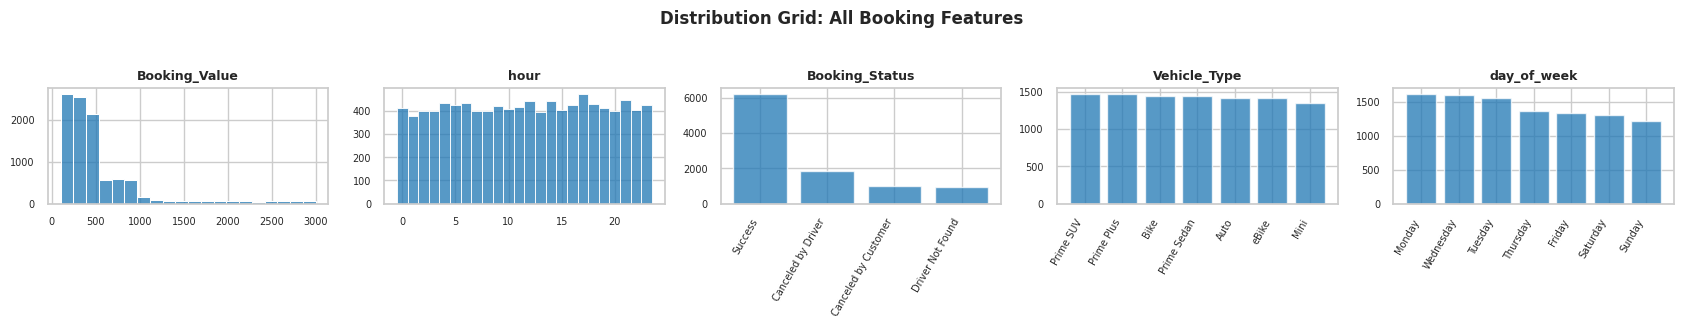

In [50]:
# Multi-panel distribution grid for every predictor + target (Rubric A3)
# Numeric columns -> histograms, categorical columns -> count bars, same layout as the regression grid
clf_num_cols = clf_raw.select_dtypes(include=[np.number]).columns.tolist()
clf_cat_cols = [c for c in clf_raw.columns if c not in clf_num_cols]
grid_cols = clf_num_cols + clf_cat_cols

n_cols = min(5, len(grid_cols))
n_rows = (len(grid_cols) + n_cols - 1) // n_cols
bar_color = '#1f77b4'

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.4 * n_cols, 3.2 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, col in enumerate(grid_cols):
    ax = axes[idx]
    if col in clf_num_cols:
        is_discrete = clf_raw[col].nunique() <= 31   # e.g. hour -> one bar per value
        sns.histplot(clf_raw[col], ax=ax, color=bar_color, kde=False,
                     discrete=is_discrete, bins='auto' if is_discrete else 20)
    else:
        counts = clf_raw[col].value_counts()
        ax.bar(counts.index.astype(str), counts.values, color=bar_color, alpha=0.75)
        ax.tick_params(axis='x', rotation=60)
        for lbl in ax.get_xticklabels():
            lbl.set_ha('right')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=7)

for idx in range(len(grid_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Distribution Grid: All Booking Features", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** a single view of every column in the booking data — `Booking_Value` and `hour` show their spread and any gaps, while the categorical bars show how evenly `Vehicle_Type` and `day_of_week` are populated and how dominant the Success class is in `Booking_Status`.

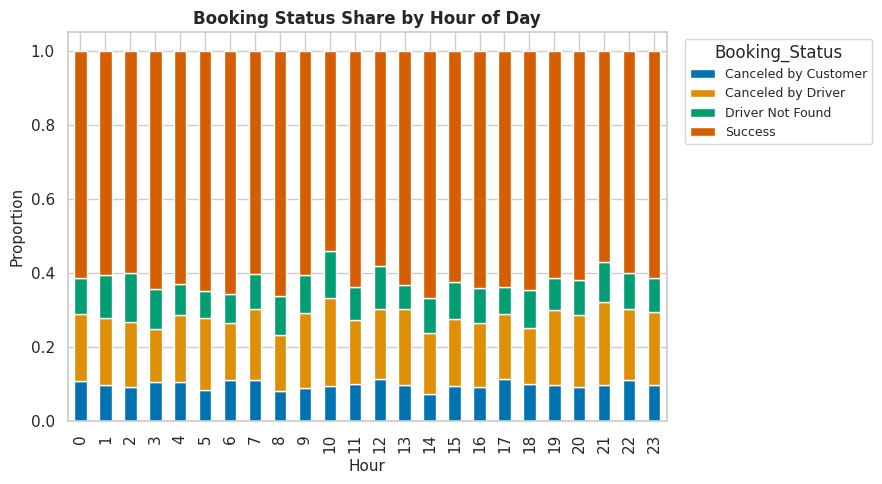

In [51]:
status_by_hour = pd.crosstab(clf_raw['hour'], clf_raw['Booking_Status'], normalize='index')

fig, ax = plt.subplots(figsize=(9, 5))
status_by_hour.plot(kind='bar', stacked=True, color=sns.color_palette("colorblind", n_colors=status_by_hour.shape[1]), ax=ax)
ax.set_title("Booking Status Share by Hour of Day", fontsize=12, fontweight='bold')
ax.set_xlabel("Hour", fontsize=11)
ax.set_ylabel("Proportion", fontsize=11)
ax.legend(title='Booking_Status', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** cancellation share looks fairly stable across hours, without an obvious peak-hour spike — hour-of-day alone looks like a weak predictor of cancellation.

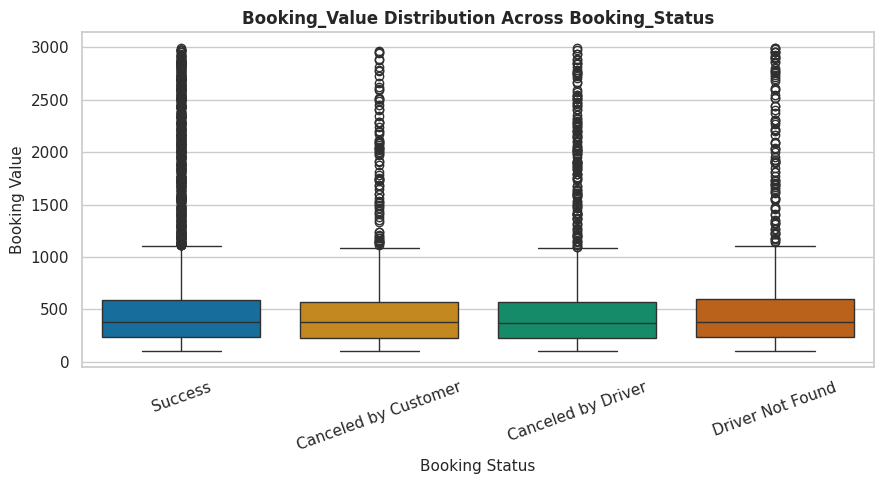

In [52]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='Booking_Status', y='Booking_Value', data=clf_raw, hue='Booking_Status',
            palette='colorblind', legend=False)
plt.title("Booking_Value Distribution Across Booking_Status", fontsize=12, fontweight='bold')
plt.xlabel("Booking Status", fontsize=11)
plt.ylabel("Booking Value", fontsize=11)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
plt.close('all')


**Insight:** `Booking_Value` distributions look similar across all four outcome classes — the quoted value alone doesn't obviously separate successful from cancelled rides.

## Section B — Preprocessing Pipeline

The diagram below summarises the cleaning, encoding, scaling, and stratified split applied before any model training.

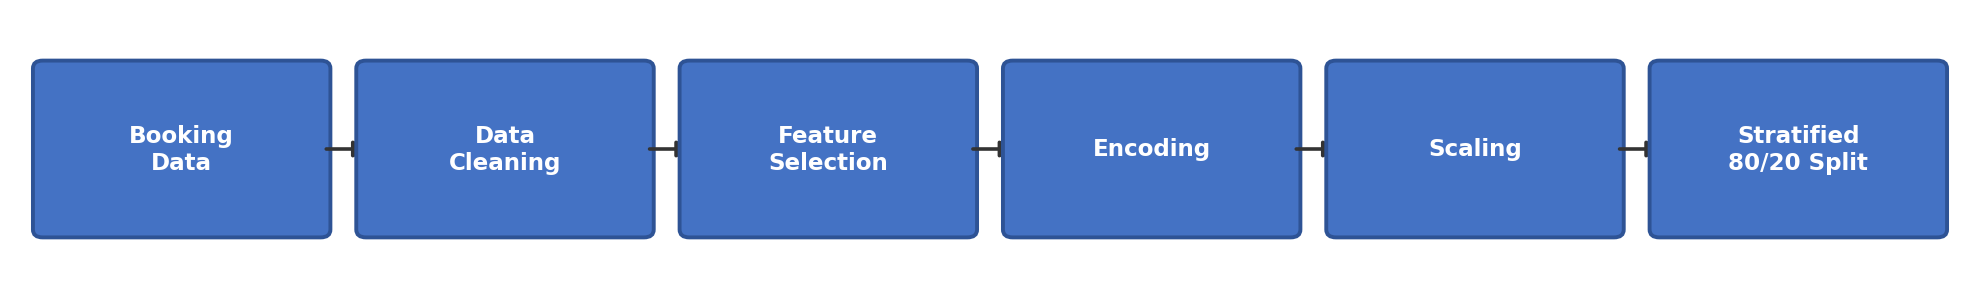

In [53]:
from IPython.display import Image, display
display(Image('pipeline_classification.png'))


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

clf_features_num = ['Booking_Value', 'hour']
clf_features_cat = ['Vehicle_Type', 'day_of_week']
clf_target = 'Booking_Status'

X_clf = clf_raw[clf_features_num + clf_features_cat]
y_clf = clf_raw[clf_target]

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

clf_preprocess = ColumnTransformer([
    ('num', StandardScaler(), clf_features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), clf_features_cat)
])

print("Train/test shapes:", X_clf_train.shape, X_clf_test.shape)
print(y_clf_train.value_counts(normalize=True).round(3))


Train/test shapes: (8000, 4) (2000, 4)
Booking_Status
Success                 0.621
Canceled by Driver      0.184
Canceled by Customer    0.098
Driver Not Found        0.097
Name: proportion, dtype: float64


Note: predictors deliberately **exclude** `V_TAT`, `C_TAT`, ratings, `Ride_Distance`, and `Payment_Method` — all only known once a ride has already completed, so including them would leak the outcome we're trying to predict.

## Section D — Classification Track, Part A (5 Algorithms)

Each algorithm below is trained, evaluated, and recorded in its own cell.

In [55]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)
from sklearn.preprocessing import label_binarize

classes = sorted(y_clf.unique())
y_clf_test_bin = label_binarize(y_clf_test, classes=classes)

clf_results_registry = []
fitted_clf_pipelines = {}

def evaluate_classifier(name, model, X_train, y_train, X_test, y_test):
    pipe = Pipeline([('prep', clf_preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    if hasattr(pipe, 'predict_proba'):
        roc_auc = roc_auc_score(y_clf_test_bin, pipe.predict_proba(X_test), average='weighted', multi_class='ovr')
    else:
        roc_auc = np.nan

    clf_results_registry.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec,
                                  'F1 (weighted)': f1, 'ROC-AUC (OvR)': roc_auc})
    fitted_clf_pipelines[name] = pipe
    print(f"{name:28s} Acc={acc:.4f}  Prec={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  AUC={roc_auc:.4f}")
    return pipe


### 1. Logistic Regression
Models the probability of each `Booking_Status` class as a (multinomial) logistic function of the features. Baseline classifier.

In [56]:
from sklearn.linear_model import LogisticRegression
_ = evaluate_classifier('Logistic Regression', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                         X_clf_train, y_clf_train, X_clf_test, y_clf_test)


Logistic Regression          Acc=0.6210  Prec=0.3856  Recall=0.6210  F1=0.4758  AUC=0.4908


### 2. K-Nearest Neighbors
Classifies a booking by majority vote among the k most similar bookings (by feature distance) in the training set.

In [57]:
from sklearn.neighbors import KNeighborsClassifier
_ = evaluate_classifier('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=7),
                         X_clf_train, y_clf_train, X_clf_test, y_clf_test)


K-Nearest Neighbors          Acc=0.5540  Prec=0.4286  Recall=0.5540  F1=0.4735  AUC=0.5028


### 3. Naive Bayes (Gaussian)
Applies Bayes' theorem assuming features are conditionally independent given the class — fast and often a strong baseline.

In [58]:
from sklearn.naive_bayes import GaussianNB
_ = evaluate_classifier('Naive Bayes (Gaussian)', GaussianNB(),
                         X_clf_train, y_clf_train, X_clf_test, y_clf_test)


Naive Bayes (Gaussian)       Acc=0.6205  Prec=0.4100  Recall=0.6205  F1=0.4766  AUC=0.4926


### 4. Decision Tree Classifier
Splits bookings on feature thresholds, building a tree of if/else rules that separates the outcome classes.

In [59]:
from sklearn.tree import DecisionTreeClassifier
_ = evaluate_classifier('Decision Tree Classifier', DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
                         X_clf_train, y_clf_train, X_clf_test, y_clf_test)


Decision Tree Classifier     Acc=0.6010  Prec=0.4132  Recall=0.6010  F1=0.4739  AUC=0.4858


### 5. Support Vector Machine (SVC)
Finds a decision boundary (via a kernel) that best separates the booking-outcome classes with maximum margin.

In [60]:
from sklearn.svm import SVC
_ = evaluate_classifier('Support Vector Machine (SVC)', SVC(kernel='rbf', C=5, probability=True, random_state=RANDOM_STATE),
                         X_clf_train, y_clf_train, X_clf_test, y_clf_test)


Support Vector Machine (SVC) Acc=0.6170  Prec=0.4463  Recall=0.6170  F1=0.4757  AUC=0.5051


### Consolidated Part-A comparison table

In [61]:
clf_results_df = pd.DataFrame(clf_results_registry).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
clf_results_df.round(4)


,Model,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC (OvR)
0,Naive Bayes (Gaussian),0.6205,0.4100,0.6205,0.4766,0.4926
1,Logistic Regression,0.6210,0.3856,0.6210,0.4758,0.4908
2,Support Vector Machine (SVC),0.6170,0.4463,0.6170,0.4757,0.5051
3,Decision Tree Classifier,0.6010,0.4132,0.6010,0.4739,0.4858
4,K-Nearest Neighbors,0.5540,0.4286,0.5540,0.4735,0.5028


### Confusion matrices — all 5 Part-A algorithms

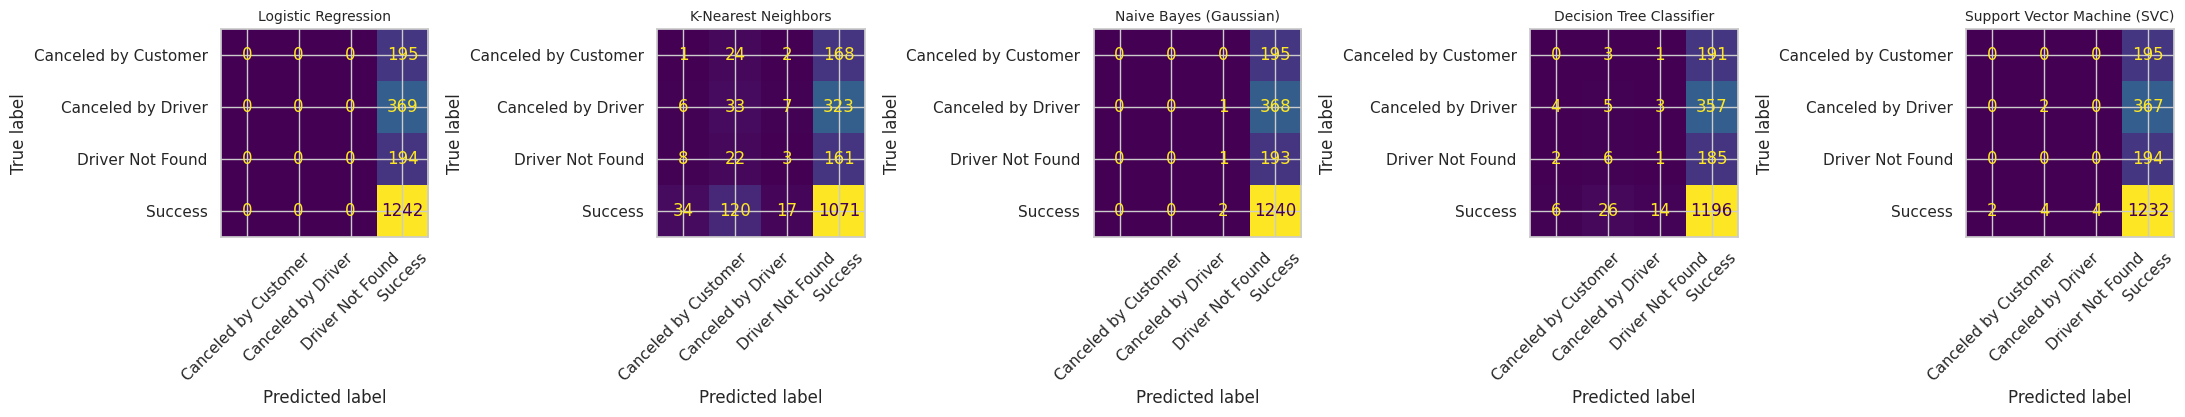

In [62]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for ax, (name, pipe) in zip(axes.ravel(), fitted_clf_pipelines.items()):
    y_pred = pipe.predict(X_clf_test)
    cm = confusion_matrix(y_clf_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()


**Interpretation:** Given the ~62/13/10/10 class split, a model that always predicts "Success" would
already score ~62% accuracy — which is why weighted F1 (used to rank the table above) and the confusion
matrices matter more here than raw accuracy alone. Scores across all 5 Part-A models sit close to that
majority-class baseline, an honest finding that the available features (`Booking_Value`, `hour`, `Vehicle_Type`,
`day_of_week`) only weakly predict cancellations.

In [63]:
best_clf_name = clf_results_df.iloc[0]['Model']
print(f"Best Part-A model by weighted F1: {best_clf_name}")


Best Part-A model by weighted F1: Naive Bayes (Gaussian)


# Final Results — All Models in One Place
Every model trained in this notebook, collected into two final tables: one for the Regression track (R², MAE, RMSE) and one for the Classification track (F1, Accuracy, Precision, Recall, ROC-AUC).

### Regression — R², MAE and RMSE for all 10 algorithms

In [64]:
# ---------- FINAL TABLE 1: all 10 regression models ----------
from IPython.display import display

final_reg_table = (pd.concat([linear_family_results_df, results_df], ignore_index=True)
                     .sort_values('R2', ascending=False)
                     .reset_index(drop=True))
final_reg_table.insert(0, 'Rank', range(1, len(final_reg_table) + 1))
final_reg_table = final_reg_table[['Rank', 'Model', 'R2', 'MAE', 'RMSE']].round(4)

print("REGRESSION — All 10 models (Uber Fares, target = fare_amount)  |  sorted by R2, higher is better")
display(final_reg_table.style.hide(axis='index').format(precision=4))
best_reg = final_reg_table.iloc[0]
print(f"Best regression model: {best_reg['Model']}  (R2 = {best_reg['R2']:.4f}, MAE = {best_reg['MAE']:.4f})")


REGRESSION — All 10 models (Uber Fares, target = fare_amount)  |  sorted by R2, higher is better


Rank,Model,R2,MAE,RMSE
1,Gradient Boosting Regressor,0.8000,2.2590,4.0249
2,Lasso Regression,0.7755,2.3800,4.2634
3,Linear Regression,0.7749,2.3789,4.2693
4,Ridge Regression,0.7749,2.3789,4.2694
5,ElasticNet Regression,0.7704,2.4299,4.3118
6,Support Vector Regressor (SVR),0.7685,2.2650,4.3294
7,Polynomial Regression (deg=2),0.7652,2.4097,4.3602
8,Random Forest Regressor,0.7627,2.4597,4.3833
9,Decision Tree Regressor,0.7238,2.5003,4.7295
10,K-Nearest Neighbors Regressor,0.7111,2.8334,4.8366


Best regression model: Gradient Boosting Regressor  (R2 = 0.8000, MAE = 2.2590)


### Classification — F1 score and other metrics for all 5 algorithms

In [65]:
# ---------- FINAL TABLE 2: all 5 classification models ----------
from IPython.display import display

final_clf_table = (pd.DataFrame(clf_results_registry)
                     .sort_values('F1 (weighted)', ascending=False)
                     .reset_index(drop=True))
final_clf_table.insert(0, 'Rank', range(1, len(final_clf_table) + 1))
final_clf_table = final_clf_table[['Rank', 'Model', 'F1 (weighted)', 'Accuracy',
                                   'Precision', 'Recall', 'ROC-AUC (OvR)']].round(4)

print("CLASSIFICATION — All 5 Part-A models (Ola & Uber Bookings, target = Booking_Status)  |  sorted by weighted F1")
display(final_clf_table.style.hide(axis='index').format(precision=4))
best_clf = final_clf_table.iloc[0]
print(f"Best classification model: {best_clf['Model']}  (F1 = {best_clf['F1 (weighted)']:.4f}, Accuracy = {best_clf['Accuracy']:.4f})")


CLASSIFICATION — All 5 Part-A models (Ola & Uber Bookings, target = Booking_Status)  |  sorted by weighted F1


Rank,Model,F1 (weighted),Accuracy,Precision,Recall,ROC-AUC (OvR)
1,Naive Bayes (Gaussian),0.4766,0.6205,0.4100,0.6205,0.4926
2,Logistic Regression,0.4758,0.6210,0.3856,0.6210,0.4908
3,Support Vector Machine (SVC),0.4757,0.6170,0.4463,0.6170,0.5051
4,Decision Tree Classifier,0.4739,0.6010,0.4132,0.6010,0.4858
5,K-Nearest Neighbors,0.4735,0.5540,0.4286,0.5540,0.5028


Best classification model: Naive Bayes (Gaussian)  (F1 = 0.4766, Accuracy = 0.6205)


## Summary
5 Part-A classification algorithms trained and compared on the Ola & Uber Booking dataset, with post-outcome
fields explicitly excluded to prevent leakage. Part B (5 more algorithms) and the full 10-model comparison
are scoped for Review 2.